# Wheat aphid population dynamics under catastrophe theory

A reimplementation and interactive simulation of

> Li Y., Hu Z., Li Z., Kong Y., Piyaratne M.K.D.K., Wang B., Zhao H. (2020).
> *Generalized population dynamics model of aphids in wheat based on catastrophe theory.*
> **BioSystems** 198:104217.

Everything runs off the paper's two supplementary datasets, S1 (aphid and
natural-enemy counts, 1997–2002) and S2 (meteorological rolling averages).

**The model (Eq. 5), with θ = 1 and δ = 2:**

$$\frac{dN}{dt} = r\,m\,N\left(1 - \frac{e\,N}{K}\right) - \frac{P\,k\,N^{2}}{N^{2}+d^{2}}$$

| symbol | meaning |
|---|---|
| $N$ | aphids per 100 stems, the state variable |
| $e$ | composite meteorological index (catastrophe-progression method) |
| $P$ | natural enemies in standard predator units (PU) per 100 stems |
| $m$ | survival rate under insecticide (1 = no spray) |
| $r, K, k, d$ | intrinsic rate of increase, carrying capacity, predation rate, half-saturation |

Substituting $N = x + K/3e$ removes the quadratic term and leaves the **cusp
catastrophe** $x^3 + ux + v = 0$. The sign of $\Delta = 27v^2 + 4u^3$ splits the
control panel into region **I** (one low-density equilibrium), **II** (bistable , 
the catastrophic region) and **III** (one high-density equilibrium).

## What this notebook does

1. Loads and reproduces the paper's pipeline, checked against its published tables
2. Runs the two-stage parameter estimation
3. Shows why **Eq. (5) cannot be integrated as published**, and what to do instead
4. Provides an **interactive simulator** with sliders
5. Tests whether the region classification actually predicts outbreaks

## 0. Setup

In [1]:
import sys, warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
warnings.filterwarnings("ignore")

import gpd                 # the paper's model, verbatim
import sim_variant as sv   # the repaired, integrable variant

pd.set_option("display.width", 200)
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True,
                     "grid.alpha": 0.25, "legend.frameon": False,
                     "figure.facecolor": "white", "axes.axisbelow": True})

YEARS = (1997, 1998, 1999, 2000, 2001, 2002)
YCOL = dict(zip(YEARS, ["#4c3f91", "#1f6feb", "#12a4a4", "#4aa02c", "#e8a33d", "#c0392b"]))
RCOL = {"I": "#2b8a3e", "II": "#e8a33d", "III": "#c0392b"}
print("ready")

ready


## 1. Load the data

`load_survey` reads Dataset S1 and applies the **natural-enemy unitization** of
Section 2.4.2, each taxon converted to standard predator units via Table 1
(ladybirds 1, spiders 0.25, hoverflies 0.5, lacewings 0.5, parasitoids 1/120).

In [2]:
survey  = gpd.load_survey()
weather = gpd.load_weather()

print(f"{len(survey)} survey dates, {len(weather)} daily weather records")
survey.head(8)

62 survey dates, 366 daily weather records


,no,year,month,day,date,t,lady,para,spid,hover,lace,N,P,m
0,1,1997,4,7,Apr.7,7,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,1.0
1,2,1997,4,12,Apr.12,12,1.0,0.0,0.0,0.0,0.0,8.0,1.000000,1.0
2,3,1997,4,17,Apr.17,17,0.0,0.0,1.0,1.0,1.0,12.0,1.250000,1.0
3,4,1997,4,22,Apr.22,22,3.0,1.0,0.0,0.0,0.0,43.0,3.008333,1.0
4,5,1997,4,30,Apr.30,30,1.0,2.0,1.0,1.0,0.0,335.0,1.766667,1.0
5,6,1997,5,6,May.6,36,2.0,4.0,1.0,3.0,1.0,591.0,4.283333,1.0
6,7,1997,5,17,May.17,47,0.0,12.0,1.0,0.0,1.0,78.0,0.850000,1.0
7,8,1997,5,20,May.20,50,2.0,44.0,0.0,1.0,0.0,375.0,2.866667,1.0


### The meteorological factor $e$

Section 2.4.1's **catastrophe-progression method**: the four indices retained by
the Spearman screening (Table A1) are normalised, passed through the butterfly
membership functions $x_a = z^{1/2},\, x_b = z^{1/3},\, x_c = z^{1/4},\, x_d = z^{1/5}$,
combined by the *non-complementary* rule $X_e = \min\{x_a, x_b, x_c, x_d\}$, and
standardised.

Two details the paper leaves implicit, recovered by matching its published values:
the normalisation and standardisation constants come from **all daily April–May
records of 1997–2001** (not just survey dates), and the combination rule is the
minimum, not the mean.

In [3]:
scaler = gpd.CPScaler.fit(weather)          # constants fixed on 1997-2001
df = gpd.add_weather_index(survey, weather, scaler)
df = gpd.cusp_table(df, gpd.PAPER_BETA)     # adds u, v, Delta, region

df[["no", "year", "date", "t", "N", "P", "m", "e", "region"]].head(10)

,no,year,date,t,N,P,m,e,region
0,1,1997,Apr.7,7,0.0,0.000000,1.0,-2.634930,I
1,2,1997,Apr.12,12,8.0,1.000000,1.0,-1.063803,I
2,3,1997,Apr.17,17,12.0,1.250000,1.0,-0.468901,I
3,4,1997,Apr.22,22,43.0,3.008333,1.0,-0.222781,I
4,5,1997,Apr.30,30,335.0,1.766667,1.0,-0.222781,I
5,6,1997,May.6,36,591.0,4.283333,1.0,0.066302,III
6,7,1997,May.17,47,78.0,0.850000,1.0,-0.188835,I
7,8,1997,May.20,50,375.0,2.866667,1.0,0.188483,III
8,9,1997,May.30,60,540.0,4.308333,1.0,0.918476,III
9,10,1998,Apr.1,1,6.0,1.250000,1.0,-2.810921,I


## 2. Validation against the published tables

`data/table3_published.csv` and `data/tableA2_published.csv` were extracted
directly from the article PDF by `src/extract_tables.py`. This is the check that
the reimplementation is faithful.

In [4]:
pub   = pd.read_csv("data/table3_published.csv")
pubA2 = pd.read_csv("data/tableA2_published.csv")
chk = df.merge(pub, on="no", suffixes=("", "_pub")).merge(pubA2, on="no")

print(f"e         max |diff|   {(chk.e - chk.e_pub).abs().max():.5f}")
print(f"P (PU)    max |diff|   {(chk.P - chk.P_pub).abs().max():.4f}")
print(f"N         max |diff|   {(chk.N - chk.N_pub).abs().max():.1f}")
for col, pubcol, scale in (("u", "u_e12", 1e12), ("v", "v_e18", 1e18),
                           ("delta", "delta_e36", 1e36)):
    rel = ((chk[col] / scale - chk[pubcol]).abs() / chk[pubcol].abs())
    print(f"{col:<9} median rel   {rel.median():.2e}    max {rel.max():.2e}")
print(f"\nregion    {(chk.region == chk.region_pub).sum()}/{len(chk)} identical")

e         max |diff|   0.00127
P (PU)    max |diff|   0.0533
N         max |diff|   0.0
u         median rel   7.08e-04    max 2.07e-02
v         median rel   1.06e-03    max 3.12e-02
delta     median rel   1.50e-03    max 4.16e-02

region    62/62 identical


### A numerical trap worth knowing about

$\Delta = 27v^2 + 4u^3$ should not be computed that way. With the fitted
$K \approx 2.75\times10^{7}$, both terms are of order $10^{41}$ while $\Delta$
itself is of order $10^{34}$, so **up to 12.1 decimal digits cancel**, and double
precision, which carries about 15.95, is left with roughly 3.8.

The paper's Eq. (14) gives an algebraically equivalent factored form in
$\xi = K/e$ and $\eta = kP/rm$ that never forms the cancelling difference. (I
checked the two are identical with `sympy`.) `gpd.cusp_variables` uses it.

Measured against an 80-digit evaluation from exact inputs:

| route | median rel. error | worst |
|---|---|---|
| naive $27v^2 + 4u^3$ | $8\times10^{-8}$ | $8\times10^{-5}$ |
| Eq. (14) factored | $2\times10^{-16}$ | $3\times10^{-15}$ |

On *this* dataset the naive form still gets the **sign** of $\Delta$ right
everywhere, so the region labels survive it, but with under four significant
digits of margin in the worst case, that is luck rather than a method.

In [5]:
from decimal import Decimal as D, getcontext
getcontext().prec = 80

# exact Delta for every survey date, straight from (e, P, m) and the parameters
b = gpd.PAPER_BETA
R, K_, k_, d_ = (D(b[name]) for name in ("r", "K", "k", "d"))
true = []
for e_, P_, m_ in zip(df.e, df.P, df.m):
    xi, eta = K_ / D(e_), k_ * D(P_) / (R * D(m_))
    u_ = d_ * d_ - xi * xi / 3 + eta * xi
    v_ = eta * xi * xi / 3 - 2 * xi**3 / 27 - 2 * d_ * d_ * xi / 3
    true.append(float(27 * v_ * v_ + 4 * u_**3))
true = np.array(true)

naive = 27 * df.v.to_numpy()**2 + 4 * df.u.to_numpy()**3
for label, val in [("naive 27v^2 + 4u^3", naive), ("Eq. (14) factored", df.delta.to_numpy())]:
    rel = np.abs(val - true) / np.abs(true)
    print(f"  {label:<22} median rel err {np.median(rel):.2e}   max {rel.max():.2e}")

w = int(np.argmax(np.abs(naive - true) / np.abs(true)))
print(f"\nworst case, NO {df.no.iloc[w]} (e = {df.e.iloc[w]:.5f}):")
print(f"   27v^2    = {27 * df.v.iloc[w]**2: .10e}")
print(f"   4u^3     = {4 * df.u.iloc[w]**3: .10e}")
print(f"   exact    = {true[w]: .10e}")
print(f"   naive    = {naive[w]: .10e}   <- only ~4 significant digits survive")
print(f"   Eq. (14) = {df.delta.iloc[w]: .10e}")
print(f"\nsign of Delta (hence the region) ever wrong with the naive form? "
      f"{bool((np.sign(naive) != np.sign(true)).any())}")

  naive 27v^2 + 4u^3     median rel err 8.36e-08   max 7.61e-05
  Eq. (14) factored      median rel err 1.85e-16   max 2.70e-15

worst case, NO 46 (e = -0.00917):
   27v^2    =  1.0862667373e+56
   4u^3     = -1.0862667373e+56
   exact    =  7.9767005834e+43
   naive    =  7.9773075842e+43   <- only ~4 significant digits survive
   Eq. (14) =  7.9767005834e+43

sign of Delta (hence the region) ever wrong with the naive form? False


## 3. Two-stage parameter estimation (Section 2.4.4 / Appendix A)

**Stage 1** fits a cubic interpolating B-spline through each season's counts and
differentiates it, the MATLAB `spapi(4, Time, N)` / `fnder` pair, reproduced with
`scipy`'s `make_interp_spline` on the same averaged (`aveknt`) knot vector.
**Stage 2** is least squares of the model rate against those spline derivatives.

In [6]:
s1 = gpd.stage_one(df)                       # spline derivative at every survey point
beta_fit, se_fit, r2_fit = gpd.stage_two(s1) # least squares for r, K, k, d

est = pd.DataFrame({
    "parameter": ["r", "K", "k", "d"],
    "paper beta0":  [gpd.PAPER_BETA0[p] for p in ("r", "K", "k", "d")],
    "paper beta":   [gpd.PAPER_BETA[p]  for p in ("r", "K", "k", "d")],
    "reproduced":   [beta_fit[p]        for p in ("r", "K", "k", "d")],
    "std error":    [se_fit[p]          for p in ("r", "K", "k", "d")]})
print(est.to_string(index=False, float_format=lambda v: f"{v:,.4f}"))
print(f"\nR^2 = {r2_fit:.4f}      (paper reports 0.6473)")

parameter  paper beta0      paper beta           reproduced                   std error
        r       0.9580          0.3930               0.4119                      0.0805
        K   9,648.8850 27,523,156.8180 119,702,068,495.3279 96,419,841,346,992,816.0000
        k       1.5760         94.3150              99.9583                     19.3133
        d       9.7060        696.6500             721.8776                    109.9488

R^2 = 0.6375      (paper reports 0.6473)


`r`, `k` and `d` land close to the published values. **`K` does not, and cannot**.
it is not identifiable from these data. The paper's own standard error for it,
$4.2\times10^{-10}$ on an estimate of $2.75\times10^{7}$, is the signature of a
parameter the likelihood is flat in. The profile below shows it directly: $R^2$ is
unchanged across five orders of magnitude of `K`.

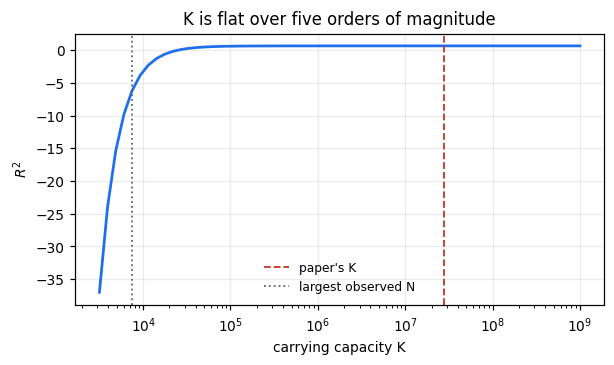

In [7]:
Ks = np.logspace(3.5, 9, 60)
prof = []
for K in Ks:
    pred = gpd.dNdt(s1.N, s1.e, s1.P, s1.m, r=beta_fit["r"], K=K,
                    k=beta_fit["k"], d=beta_fit["d"])
    prof.append(gpd.r_squared(s1.dN_spline, pred))

fig, ax = plt.subplots(figsize=(6.2, 3.2))
ax.semilogx(Ks, prof, lw=1.8, color="#1f6feb")
ax.axvline(gpd.PAPER_BETA["K"], color="#c0392b", ls="--", lw=1.2, label="paper's K")
ax.axvline(df.N.max(), color="0.4", ls=":", lw=1.2, label="largest observed N")
ax.set(xlabel="carrying capacity K", ylabel="$R^2$",
       title="K is flat over five orders of magnitude")
ax.legend(fontsize=8); plt.show()

## 4. The control panel

The paper's control variables reach $|u| \sim 10^{12}$ and $|v| \sim 10^{18}$,
which makes them hard to read. But almost all of that magnitude is $K/e$ scaling
that cancels out of $\Delta$. Working through the algebra, the bifurcation set
collapses to a threshold on **predator pressure alone**:

$$P^{*} = \frac{2\,d\,r\,m}{k}$$

≈ **5.81 PU/100 stems** normally, halved to **2.90** on a spray day. Together with
the sign of $e$ this reproduces all 62 published region labels exactly.

In [8]:
b = gpd.PAPER_BETA
P_star = 2 * b["d"] * b["r"] * df.m / b["k"]
simple = np.where(df.P > P_star, "II", np.where(df.e < 0, "I", "III"))
print(f"simple rule vs full cusp algebra: {(simple == df.region).sum()}/{len(df)} identical")
print(f"P* (no spray)  = {2 * b['d'] * b['r'] * 1.0 / b['k']:.4f} PU / 100 stems")
print(f"P* (spray day) = {2 * b['d'] * b['r'] * 0.5 / b['k']:.4f} PU / 100 stems")

simple rule vs full cusp algebra: 62/62 identical
P* (no spray)  = 5.8057 PU / 100 stems
P* (spray day) = 2.9029 PU / 100 stems


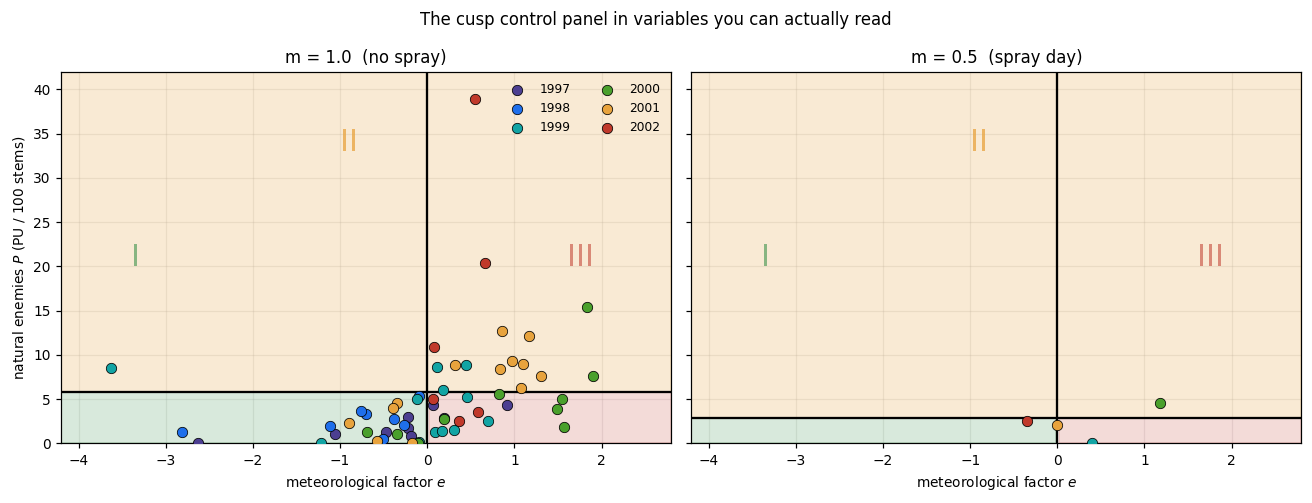

In [9]:
from scipy.optimize import brentq

def p_star_exact(e, m, beta, hi=80.0):
    e = e if abs(e) > 1e-9 else 1e-9
    f = lambda P: gpd.cusp_variables(e, P, m, **beta)[2]
    return brentq(f, 1e-9, hi, xtol=1e-12) if f(1e-9) * f(hi) < 0 else np.nan

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), sharey=True)
e_grid = np.linspace(-4.2, 2.8, 200)
for ax, m in zip(axes, (1.0, 0.5)):
    Ps = np.array([p_star_exact(e, m, b) for e in e_grid])
    ax.fill_between(e_grid, Ps, 42, color=RCOL["II"], alpha=0.22)
    ax.fill_between(e_grid, 0, Ps, where=e_grid < 0,  color=RCOL["I"],   alpha=0.18)
    ax.fill_between(e_grid, 0, Ps, where=e_grid >= 0, color=RCOL["III"], alpha=0.18)
    ax.plot(e_grid, Ps, "k", lw=1.5); ax.axvline(0, color="k", lw=1.5)
    for txt, x, c in (("I", -3.4, "I"), ("III", 1.6, "III")):
        ax.text(x, 20, txt, fontsize=20, color=RCOL[c], alpha=0.55)
    ax.text(-1.0, 33, "II", fontsize=20, color=RCOL["II"], alpha=0.75)
    sel = df[df.m == m]
    for year in YEARS:
        g = sel[sel.year == year]
        if len(g):
            ax.scatter(g.e, g.P, s=46, color=YCOL[year], edgecolor="k",
                       linewidth=0.5, label=str(year), zorder=5)
    ax.set(xlim=(-4.2, 2.8), ylim=(0, 42), xlabel="meteorological factor $e$",
           title=f"m = {m}" + ("  (no spray)" if m == 1 else "  (spray day)"))
axes[0].set_ylabel("natural enemies $P$ (PU / 100 stems)")
axes[0].legend(fontsize=8, ncol=2, loc="upper right")
fig.suptitle("The cusp control panel in variables you can actually read")
plt.tight_layout(); plt.show()

## 5. Every catastrophe in Table 2

Table 2 lists seven combinations of the exponents $(\theta, \delta)$ from Eq. (5),
mapping onto four catastrophe types. The paper says it made "several attempts...
until a combination of exponents are obtained that can explain the data well" and
settled on $\theta = 1,\ \delta = 2$, the cusp, without reporting the comparison.

Here you can run it. Each combination is fitted by the paper's own two-stage
method, so the $R^2$ values are directly comparable.

$$\frac{dN}{dt} = r\,m\,N\left(1 - \frac{e\,N^{\theta}}{K}\right)
  - \frac{P\,k\,N^{\delta}}{N^{\delta}+d^{\delta}}$$

The equilibrium polynomial (Eq. 10) is built generically below, so region
structure can be compared across types by counting positive equilibria, which is
the one measure that means the same thing for a fold, a cusp, a swallowtail and a
butterfly alike.

In [10]:
from scipy.optimize import curve_fit

CATASTROPHES = [(1, 1, "fold"), (1, 2, "cusp"), (2, 1, "cusp"),
                (2, 2, "swallowtail"), (3, 1, "swallowtail"),
                (3, 2, "butterfly"), (4, 1, "butterfly")]


def eq_poly(theta, delta, e, P, m, beta):
    # Eq. 10:  N^(t+d) + d^d N^t + (K/e)[(Pk/rm) N^(d-1) - N^d - d^d] = 0
    r, K, k, d = (beta[q] for q in ("r", "K", "k", "d"))
    deg = theta + delta
    c = np.zeros(deg + 1)

    def add(power, val):
        c[deg - power] += val

    add(theta + delta, 1.0)
    add(theta, d ** delta)
    add(delta - 1, K / e * (k * P / (r * m)))
    add(delta, -K / e)
    add(0, -K / e * d ** delta)
    return c


def positive_equilibria(theta, delta, e, P, m, beta):
    rts = np.roots(eq_poly(theta, delta, e, P, m, beta))
    rts = rts[np.abs(rts.imag) < 1e-6 * (1 + np.abs(rts.real))].real
    return np.sort(rts[rts > 0])


def fit_exponents(theta, delta, s1, n_starts=40, seed=0):
    # stage 2 of the two-stage method for one (theta, delta), multistarted
    X = s1[["N", "e", "P", "m"]].to_numpy(float)
    y = s1.dN_spline.to_numpy(float)

    def model(X, r, K, k, d):
        N, e, P, m = X.T
        return gpd.dNdt(N, e, P, m, r, K, k, d, theta=theta, delta=delta)

    rng = np.random.default_rng(seed)
    best = None
    for i in range(n_starts):
        p0 = ([gpd.PAPER_BETA0[q] for q in ("r", "K", "k", "d")] if i == 0 else
              [rng.uniform(0.05, 2), 10 ** rng.uniform(2, 9),
               rng.uniform(1, 500), rng.uniform(1, 3000)])
        try:
            popt, _ = curve_fit(model, X, y, p0=p0, maxfev=60_000)
        except Exception:
            continue
        if min(popt) <= 0:
            continue
        r2 = gpd.r_squared(y, model(X, *popt))
        if best is None or r2 > best[1]:
            best = (dict(zip(("r", "K", "k", "d"), popt)), r2)
    return best


FITS = {}
for th, de, name in CATASTROPHES:
    FITS[(th, de)] = fit_exponents(th, de, s1) + (name,)
print(f"fitted {len(FITS)} exponent combinations")

fitted 7 exponent combinations


In [11]:
rows = []
for (th, de), (beta, r2, name) in FITS.items():
    rows.append(dict(theta=th, delta=de, catastrophe=name, R2=round(r2, 4),
                     r=round(beta["r"], 4), K=f"{beta['K']:.3g}",
                     k=round(beta["k"], 2), d=round(beta["d"], 1),
                     ceiling_at_e1=f"{beta['K'] ** (1 / th):,.3g}"))
table = pd.DataFrame(rows)
print(table.to_string(index=False))
print(f"\nlargest observed density: {df.N.max():,.0f} aphids / 100 stems")
print("ceiling_at_e1 is where the brake vanishes at e = 1, i.e. (K/e)^(1/theta)")

 theta  delta catastrophe     R2      r        K      k      d ceiling_at_e1
     1      1        fold 0.6246 0.4874 6.16e+13 162.75 1300.0      6.16e+13
     1      2        cusp 0.6375 0.4119 6.41e+13  99.96  721.9      6.41e+13
     2      1        cusp 0.6246 0.4874 7.19e+15 162.75 1300.0      8.48e+07
     2      2 swallowtail 0.6375 0.4119 1.96e+15  99.96  721.9      4.42e+07
     3      1 swallowtail 0.6246 0.4874 3.81e+19 162.75 1300.0      3.36e+06
     3      2   butterfly 0.6375 0.4119 6.45e+18  99.96  721.9      1.86e+06
     4      1   butterfly 0.6246 0.4874 5.63e+22 162.75 1300.0      4.87e+05

largest observed density: 7,480 aphids / 100 stems
ceiling_at_e1 is where the brake vanishes at e = 1, i.e. (K/e)^(1/theta)


Two things to notice. $R^2$ depends only on $\delta$, never on $\theta$, and
$r$, $k$, $d$ come out identical within each $\delta$ group; only $K$ moves,
absorbing $\theta$. That is because $\theta$ only modulates a term that the fit
has already driven to zero, so **$\theta$ is unidentifiable from these data** and
fold, cusp, swallowtail and butterfly are statistically indistinguishable here.

And every ceiling is far outside the data. Even $\theta = 4$ leaves the brake
engaging two orders of magnitude above the largest count ever recorded.

In [12]:
# Does the choice of catastrophe change which dates come out bistable?
# Positive-equilibrium count is the one measure comparable across all four types.
rows = []
for (th, de), (beta, _r2, name) in FITS.items():
    cnt = [len(positive_equilibria(th, de, e_, P_, m_, beta))
           for e_, P_, m_ in zip(df.e, df.P, df.m)]
    ct = pd.crosstab(df.region, cnt)
    # a clean partition means each count sits in exactly one published region
    clean = all((ct[c] > 0).sum() == 1 for c in ct.columns)
    if clean:
        mp = {c: ct.index[np.argmax(ct[c].values)] for c in ct.columns}
        agree = f"{sum(mp[c] == r for c, r in zip(cnt, df.region))}/{len(df)}"
    else:
        agree = "-"
    rows.append(dict(catastrophe=f"{name} ({th},{de})", counts=str(sorted(set(cnt))),
                     separates_regions="yes" if clean else "no, counts overlap",
                     agreement=agree))
print(pd.DataFrame(rows).to_string(index=False))

      catastrophe       counts  separates_regions agreement
       fold (1,1)    [0, 1, 2] no, counts overlap         -
       cusp (1,2) [0, 1, 2, 3]                yes     62/62
       cusp (2,1)    [0, 1, 2] no, counts overlap         -
swallowtail (2,2) [0, 1, 2, 3]                yes     62/62
swallowtail (3,1)    [0, 1, 2] no, counts overlap         -
  butterfly (3,2) [0, 1, 2, 3]                yes     62/62
  butterfly (4,1)    [0, 1, 2] no, counts overlap         -


So it is $\delta$, not $\theta$, that does everything. The three $\delta = 2$
types, cusp, swallowtail and butterfly, produce **the identical partition of all
62 dates**, 62/62 each, with the same $r$, $k$, $d$ and the same $R^2$. Climbing
from cusp to swallowtail to butterfly is pure relabelling.

The $\delta = 1$ types are not a coarser version of the same thing, they are a
different thing: their equilibrium polynomial is one degree lower, so it cannot
resolve three regions at all and the counts overlap.

Which leaves the exponent the paper agonised over, $\theta$, doing no work
whatsoever, and the exponent it barely discusses, $\delta$, carrying the entire
structure.

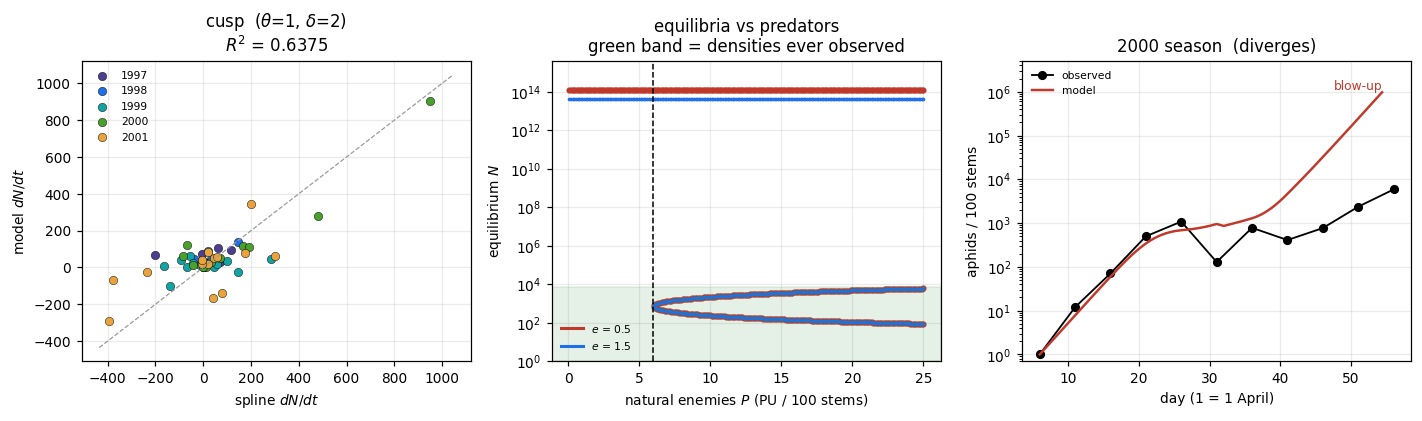

positive equilibria across the 62 dates: 0 on 27 dates, 1 on 17 dates, 2 on 1 dates, 3 on 17 dates
bistability threshold  P* = 2dr/k = 5.949 PU / 100 stems


In [13]:
def explore(theta=1, delta=2, year=2000):
    beta, r2, name = FITS[(theta, delta)]
    X = s1[["N", "e", "P", "m"]].to_numpy(float)
    y = s1.dN_spline.to_numpy(float)
    pred = gpd.dNdt(*X.T, **beta, theta=theta, delta=delta)

    fig, axes = plt.subplots(1, 3, figsize=(13, 3.9))

    ax = axes[0]
    lim = np.array([min(y.min(), pred.min()), max(y.max(), pred.max())]) * 1.1
    ax.plot(lim, lim, color="0.6", ls="--", lw=0.8)
    for yr in gpd.VALIDATION_YEARS:
        msk = (s1.year == yr).to_numpy()
        ax.scatter(y[msk], pred[msk], s=30, color=YCOL[yr], edgecolor="k",
                   linewidth=0.3, label=str(yr))
    ax.set(xlabel=r"spline $dN/dt$", ylabel="model $dN/dt$",
           title=f"{name}  ($\\theta$={theta}, $\\delta$={delta})\n$R^2$ = {r2:.4f}")
    ax.legend(fontsize=7)

    ax = axes[1]
    # e = 0.5 is drawn fat and e = 1.5 thin on top: where only blue shows, the
    # two coincide, which is itself the finding
    top = 1.0
    for e_val, c, sz in ((0.5, "#c0392b", 9), (1.5, "#1f6feb", 2)):
        for P_ in np.linspace(0.1, 25, 220):
            rts = positive_equilibria(theta, delta, e_val, P_, 1.0, beta)
            if len(rts):
                ax.scatter([P_] * len(rts), rts, s=sz, color=c)
                top = max(top, rts.max())
        ax.plot([], [], color=c, lw=2, label=f"$e$ = {e_val}")
    ax.axvline(2 * beta["d"] * beta["r"] / beta["k"], color="k", ls="--", lw=1)
    ax.axhspan(1, df.N.max(), color="#2b8a3e", alpha=0.12)
    ax.set_yscale("log"); ax.set_ylim(1, max(top * 30, 1e5))
    ax.set(xlabel="natural enemies $P$ (PU / 100 stems)", ylabel="equilibrium $N$",
           title="equilibria vs predators\ngreen band = densities ever observed")
    ax.legend(fontsize=7, loc="lower left")

    ax = axes[2]
    g = df[df.year == year].sort_values("t")
    sim_beta = dict(beta, theta=theta, delta=delta)
    t, N, blew = gpd.simulate_season(g, weather, scaler, sim_beta, year)
    ax.plot(g.t, np.maximum(g.N, 1), "o-", color="k", ms=5, lw=1.2, label="observed")
    ax.plot(t, np.maximum(N, 1), color="#c0392b", lw=1.6, label="model")
    if blew:
        ax.annotate("blow-up", (t[-1], max(N[-1], 1)), fontsize=8, color="#c0392b",
                    ha="right", va="bottom")
    ax.set_yscale("log"); ax.set_ylim(0.7, 5e6)
    ax.set(xlabel="day (1 = 1 April)", ylabel="aphids / 100 stems",
           title=f"{year} season" + ("  (diverges)" if blew else ""))
    ax.legend(fontsize=7, loc="upper left")
    plt.tight_layout(); plt.show()

    n_pos = [len(positive_equilibria(theta, delta, e_, P_, m_, beta))
             for e_, P_, m_ in zip(df.e, df.P, df.m)]
    print(f"positive equilibria across the 62 dates: "
          + ", ".join(f"{v} on {n_pos.count(v)} dates" for v in sorted(set(n_pos))))
    print(f"bistability threshold  P* = 2dr/k = "
          f"{2 * beta['d'] * beta['r'] / beta['k']:.3f} PU / 100 stems")


# the combination the paper settled on, rendered so this cell shows something
# even without a live kernel
explore(theta=1, delta=2, year=2000)

And the same for any other combination. The dropdowns need a running kernel;
without one the cell above is the static version.

In [14]:
try:
    from ipywidgets import interact, Dropdown
    interact(explore,
             theta=Dropdown(options=[1, 2, 3, 4], value=1, description="theta"),
             delta=Dropdown(options=[1, 2], value=2, description="delta"),
             year=Dropdown(options=list(YEARS), value=2000, description="year"))
except ImportError:
    print("ipywidgets not installed, so no sliders. Call explore(theta, delta, year)"
          " directly instead.")

interactive(children=(Dropdown(description='theta', options=(1, 2, 3, 4), value=1), Dropdown(description='delt…

Note that $(\theta, \delta)$ pairs outside Table 2's seven are not defined here,
so the dropdowns will raise a `KeyError` on, say, $(4, 2)$. That is Table 2's
own list, not an omission.

Whichever you pick, three things hold: the season diverges, the bistability
threshold stays at $P^* = 2dr m/k$, and within a $\delta$ group the partition of
the 62 dates does not move. Climbing the hierarchy buys nothing, which is what
&sect;9 picks up.

## 6. Why Eq. (5) cannot be integrated

The paper estimates Eq. (5) from *instantaneous rates* and never integrates it.
If you do integrate it, it runs away. Three things combine:

1. **The brake is inert.** At a field density of $N = 500$, the correction
   $1 - eN/K$ equals $1.000018$ for $e = -1$ and $0.999982$ for $e = +1$. Because
   $K \approx 2.75\times10^7$, flipping $e$ from $+2$ to $-2$ changes the growth
   rate by 0.007%.
2. **The predator saturates.** $Pk N^2/(N^2+d^2) \le Pk$, so growth $rN$ overtakes
   it permanently once $N > Pk/r$, only 1200 aphids at $P = 5$ PU.
3. **What's left is $r \approx 0.39$/day**, a doubling every 1.8 days.

The sign of $e$ decides only whether *any* ceiling exists: for $e>0$ there is an
equilibrium at $N^\* \approx K/e \approx 10^7$ (finite, but not a field density);
for $e<0$ there is no positive equilibrium at all and growth becomes quadratic,
reaching infinity in finite time.

In [15]:
from scipy.integrate import solve_ivp

print("term sizes at N = 500, P = 4, m = 1")
N, P = 500.0, 4.0
print(f"  linear growth  r*N               = {b['r'] * N:9.2f} /day")
for e in (-2, 0, 2):
    print(f"  brake          1 - e*N/K  (e={e:+d})  = {1 - e * N / b['K']:.6f}")
print(f"  predation                        = {P * b['k'] * N**2 / (N**2 + b['d']**2):9.2f} /day"
      f"   (ceiling P*k = {P * b['k']:.0f})")

print("\npositive equilibria of Eq. (11), P = 4, m = 1")
for e in (-1, -0.1, 0.1, 1, 2):
    rts = gpd.equilibria(e, 4.0, 1.0, b)
    print(f"  e = {e:+5.1f} ->  {np.array2string(rts, precision=1) if len(rts) else 'none'}")

print("\n60-day free run from N0 = 100, P = 4, e held constant")
for e in (-1, 0, 1):
    f = lambda t, y: [gpd.dNdt(max(y[0], 0), e, 4.0, 1.0, **b)]
    s = solve_ivp(f, (0, 60), [100.0], t_eval=[20, 30, 40, 50, 60],
                  method="Radau", rtol=1e-9, atol=1e-6)
    vals = "  ".join(f"{v:9.3g}" for v in s.y[0])
    tail = "" if len(s.y[0]) == 5 else "   <- integration failed: finite-time blow-up"
    print(f"  e = {e:+d}   {vals}{tail}")

term sizes at N = 500, P = 4, m = 1
  linear growth  r*N               =    196.50 /day
  brake          1 - e*N/K  (e=-2)  = 1.000036
  brake          1 - e*N/K  (e=+0)  = 1.000000
  brake          1 - e*N/K  (e=+2)  = 0.999964
  predation                        =    128.26 /day   (ceiling P*k = 377)

positive equilibria of Eq. (11), P = 4, m = 1
  e =  -1.0 ->  none
  e =  -0.1 ->  none
  e =  +0.1 ->  [2.8e+08]
  e =  +1.0 ->  [27522196.8]
  e =  +2.0 ->  [13760618.4]

60-day free run from N0 = 100, P = 4, e held constant


  e = -1    4.79e+03   1.98e+05   1.56e+07   <- integration failed: finite-time blow-up
  e = +0    4.79e+03   1.96e+05   9.94e+06   5.06e+08   2.58e+10
  e = +1    4.79e+03   1.95e+05    7.3e+06   2.61e+07   2.75e+07


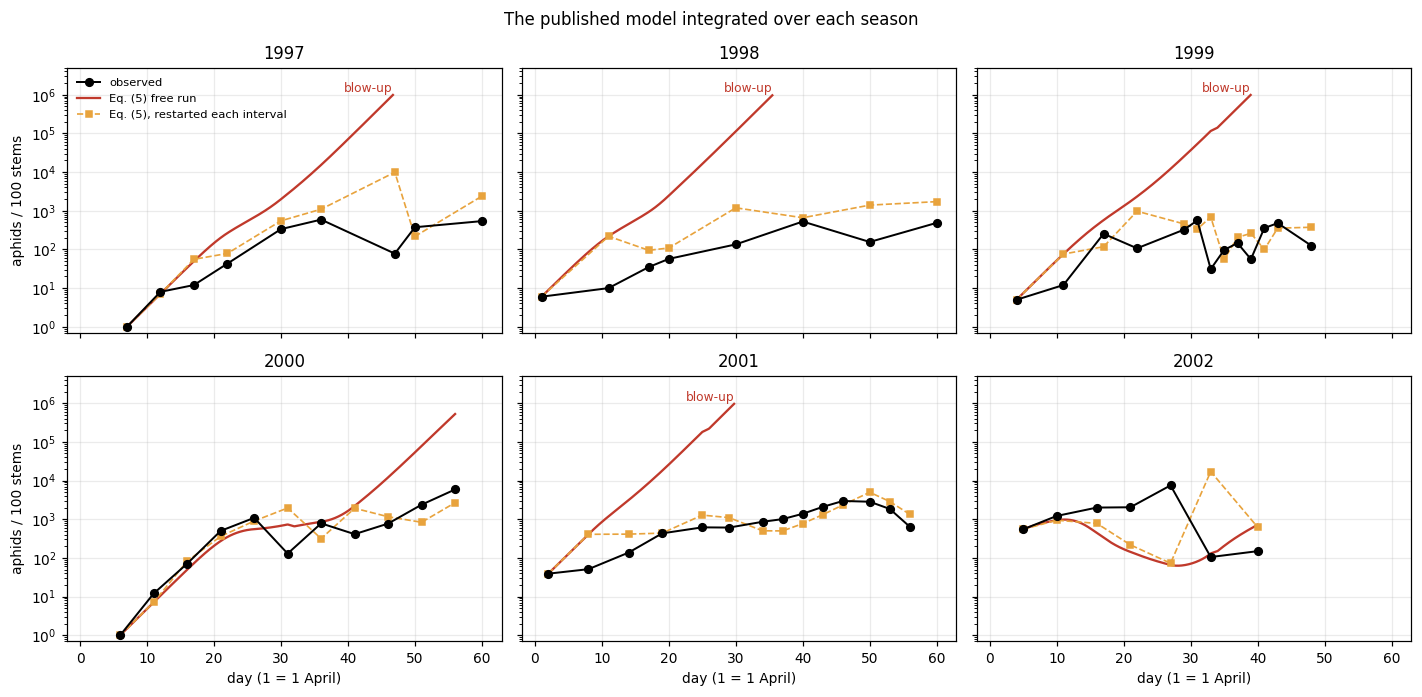

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(13, 6.4), sharex=True, sharey=True)
for ax, year in zip(axes.ravel(), YEARS):
    g = df[df.year == year].sort_values("t")
    t_f, N_f, blew = gpd.simulate_season(g, weather, scaler, b, year)
    step = gpd.simulate_stepwise(g, weather, scaler, b, year)
    ax.plot(g.t, np.maximum(g.N, 1), "o-", color="k", ms=5, lw=1.3, label="observed", zorder=5)
    ax.plot(t_f, np.maximum(N_f, 1), color="#c0392b", lw=1.5, label="Eq. (5) free run")
    ax.plot(g.t, np.maximum(step, 1), "s--", color="#e8a33d", ms=4, lw=1.1,
            label="Eq. (5), restarted each interval")
    if blew:
        ax.annotate("blow-up", (t_f[-1], max(N_f[-1], 1)), fontsize=8, color="#c0392b",
                    ha="right", va="bottom")
    ax.set_yscale("log"); ax.set_ylim(0.7, 5e6); ax.set_title(str(year))
axes[0, 0].legend(fontsize=7.5, loc="upper left")
for ax in axes[1]: ax.set_xlabel("day (1 = 1 April)")
for ax in axes[:, 0]: ax.set_ylabel("aphids / 100 stems")
fig.suptitle("The published model integrated over each season")
plt.tight_layout(); plt.show()

## 7. GPD-S, a variant that can actually be simulated

`sim_variant.py` keeps everything that carries the paper's biology (the Holling
response with $\delta=2$, predator units, the insecticide, the CP index) and makes
two minimal changes:

$$\frac{dN}{dt} = r_0 e^{a e}\, m\, N\left(1 - \frac{N}{K}\right) - \frac{P k N^2}{N^2 + d^2}$$

* **$e$ acts on the growth rate**, not the carrying capacity, the route the same
  group took in their Eq. (4) (Wu et al. 2014), where $r$ is a function of the
  temperature factor. The exponential keeps $r > 0$ for a standardised index.
* **density dependence is plain logistic**, so $K$ is a real ceiling.

This is the Ludwig–Jones–Holling form: it keeps the cusp geometry the paper is
about (refuge branch, unstable threshold, outbreak branch) at field densities.

One further correction: the insecticide is applied as an **impulse**
$N \to mN$ at the spray date. That is the paper's own definition of $m$
($m = N'_{t_0}/N_{t_0}$); folding it into the growth rate for a single day, as the
paper does "for simplicity", removes a fraction of a percent instead of half.

In [17]:
beta_s = sv.FITTED
print("GPD-S parameters (trajectory-matched on 1997-2001):")
for k_, v in beta_s.items():
    print(f"  {k_:<3} = {v:,.4f}")

print(f"\nk/d^2 = {beta_s['k'] / beta_s['d']**2:.3e}   <- the combination the data constrain")
print(f"largest observed density = {df.N.max():,.0f};  d = {beta_s['d']:,.0f}")
print("so N << d over most of the range and the Holling term is effectively "
      "(P k/d^2) N^2")

GPD-S parameters (trajectory-matched on 1997-2001):
  r0  = 0.4448
  a   = 1.1263
  K   = 7,943.3000
  k   = 37,352.0000
  d   = 10,923.9000

k/d^2 = 3.130e-04   <- the combination the data constrain
largest observed density = 7,480;  d = 10,924
so N << d over most of the range and the Holling term is effectively (P k/d^2) N^2


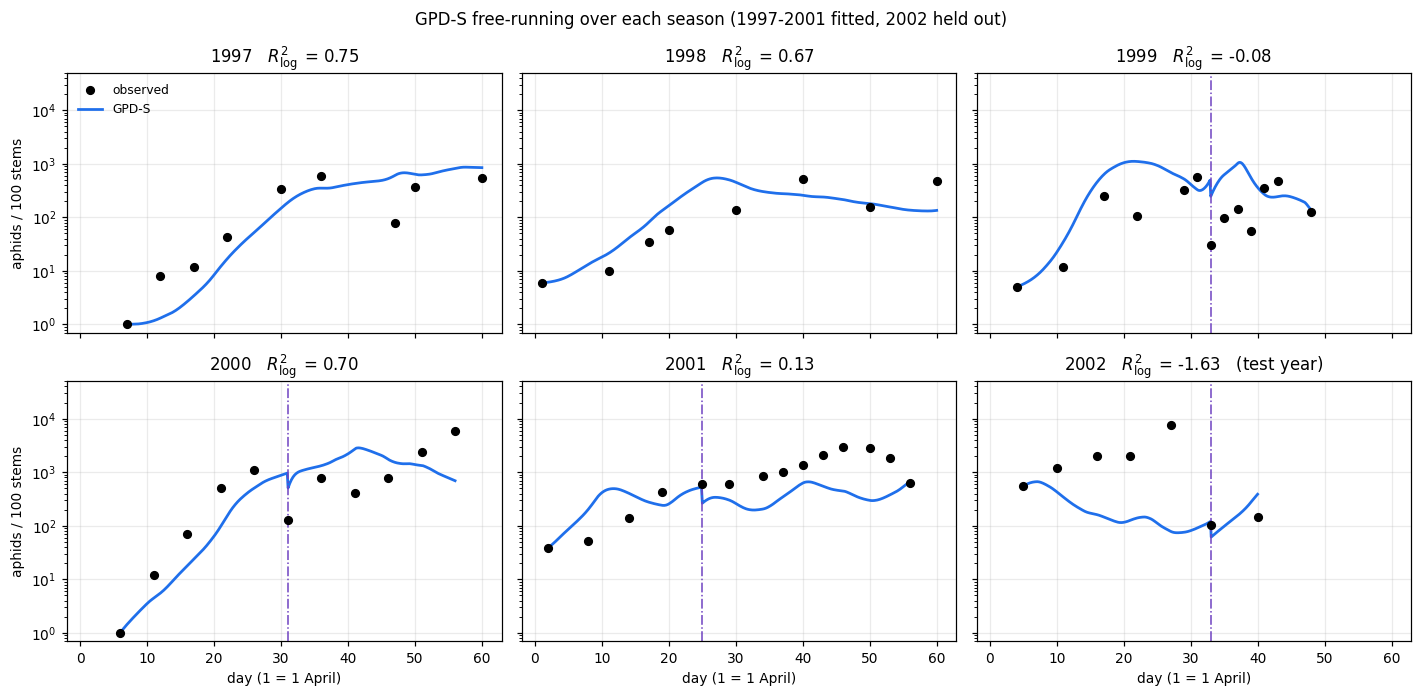

,year,obs_peak,sim_peak,r2_log
0,1997,591.0,866.371,0.749
1,1998,527.0,545.382,0.675
2,1999,562.0,1113.877,-0.075
3,2000,5870.0,2853.764,0.698
4,2001,2958.0,664.712,0.132
5,2002,7480.0,666.705,-1.631


In [18]:
fig, axes = plt.subplots(2, 3, figsize=(13, 6.4), sharex=True, sharey=True)
scores = []
for ax, year in zip(axes.ravel(), YEARS):
    g = df[df.year == year].sort_values("t")
    t, N = sv.simulate(g, weather, scaler, beta_s, year)
    pred = np.interp(g.t.to_numpy(float), t, N)
    r2 = gpd.r_squared(np.log1p(g.N), np.log1p(pred))
    scores.append(dict(year=year, obs_peak=g.N.max(), sim_peak=N.max(), r2_log=r2))
    ax.plot(g.t, np.maximum(g.N, 1), "o", color="k", ms=5, label="observed", zorder=5)
    ax.plot(t, np.maximum(N, 1), color="#1f6feb", lw=1.8, label="GPD-S")
    if year in gpd.SPRAY_DATES:
        ax.axvline(gpd._day_index(*gpd.SPRAY_DATES[year]), color="#6f42c1", lw=1.0, ls="-.")
    ax.set_yscale("log"); ax.set_ylim(0.7, 5e4)
    ax.set_title(f"{year}   $R^2_{{\\log}}$ = {r2:.2f}"
                 + ("   (test year)" if year == gpd.TEST_YEAR else ""))
axes[0, 0].legend(fontsize=8, loc="upper left")
for ax in axes[1]: ax.set_xlabel("day (1 = 1 April)")
for ax in axes[:, 0]: ax.set_ylabel("aphids / 100 stems")
fig.suptitle("GPD-S free-running over each season (1997-2001 fitted, 2002 held out)")
plt.tight_layout(); plt.show()

pd.DataFrame(scores).round(3)

**Read this honestly.** GPD-S is well-behaved where the published model is not,
it integrates, it stays at field densities, and it reproduces both catastrophe
flags. But as a *fit* it is mediocre and it does not generalise:

* 1997, 1998 and 2000 come out reasonably ($R^2_{\log}$ 0.67–0.75); 1999 and 2001 do not;
  the held-out 2002 fails badly.
* `K` sits on its lower bound. The optimiser would rather cap every season than
  reproduce the 5870 (2000) and 7480 (2002) peaks.
* `k` and `d` are identified only through `k/d²`, the cost varies by 1.2% across
  an eight-fold range of `d`, mirroring the `K` problem in the published model.

The substantive point is that **the observed forcing does not contain enough
signal** to explain why 2000 and 2002 exploded while 1997 and 1998 stayed quiet.
That is a statement about the data and the covariates, not only about this
functional form, and it is the same wall the original model runs into.

### Sudden transition and hysteresis

The two "flags" of catastrophe theory. Sweeping a control variable slowly up and
then back down: the state jumps when its branch ceases to exist (the **delay
convention**, which the paper adopts), and the return path is different, so
restoring the original conditions does *not* restore the original population.

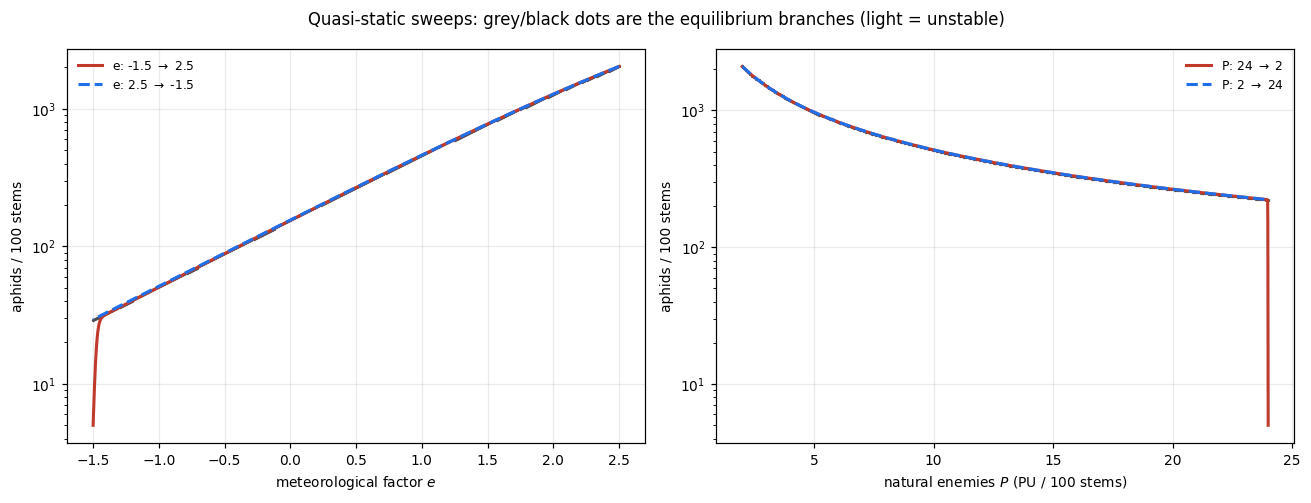

In [19]:
def sweep(beta, var, lo, hi, fixed, N0, T=4000.0):
    def ctrl(t): return lo + (hi - lo) * t / T
    def rhs(t, y):
        kw = dict(fixed); kw[var] = ctrl(t)
        return [sv.rhs(y[0], e=kw.get("e"), P=kw.get("P"), m=kw["m"], **beta)]
    s = solve_ivp(rhs, (0, T), [N0], t_eval=np.linspace(0, T, 3000),
                  method="Radau", rtol=1e-9, atol=1e-7)
    return np.array([ctrl(t) for t in s.t]), s.y[0]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
for ax, (var, lo, hi, fixed, lbl) in zip(axes, [
        ("e", -1.5, 2.5, dict(P=9.0, m=1.0), "meteorological factor $e$"),
        ("P", 24.0, 2.0, dict(e=1.2, m=1.0), "natural enemies $P$ (PU / 100 stems)")]):
    for val in np.linspace(min(lo, hi), max(lo, hi), 260):   # equilibrium branches
        kw = dict(fixed); kw[var] = val
        rts = sv.equilibria(kw.get("e"), kw.get("P"), kw["m"], beta_s)
        if len(rts):
            st = sv.stability(rts, kw.get("e"), kw.get("P"), kw["m"], beta_s)
            ax.scatter([val] * len(rts), rts, s=1.4,
                       c=["0.3" if s_ else "0.75" for s_ in st], zorder=1)
    cf, Nf = sweep(beta_s, var, lo, hi, fixed, 5.0)
    cb, Nb = sweep(beta_s, var, hi, lo, fixed, Nf[-1])
    ax.plot(cf, Nf, color="#c0392b", lw=2.0, label=f"{var}: {lo:g} $\\to$ {hi:g}")
    ax.plot(cb, Nb, color="#1f6feb", lw=2.0, ls="--", label=f"{var}: {hi:g} $\\to$ {lo:g}")
    ax.set_yscale("log"); ax.set(xlabel=lbl, ylabel="aphids / 100 stems")
    ax.legend(fontsize=8)
fig.suptitle("Quasi-static sweeps: grey/black dots are the equilibrium branches "
             "(light = unstable)")
plt.tight_layout(); plt.show()

## 8. Interactive simulator

Drag the sliders to explore. If `ipywidgets` is not installed the cell falls back
to a static figure, install with `pip install ipywidgets` for the live version.

* **year**, which season's weather and predator series to run under
* **spray day / survival m**, insecticide timing and efficacy ($m=1$ is no spray)
* **predator multiplier**, scales the observed natural-enemy series
* **N₀**, starting density

In [20]:
def run_scenario(year=2000, spray_day=31, m=0.5, predators=1.0, N0=None, ax=None):
    # simulate one season under a modified control scenario
    g = df[df.year == year].sort_values("t")
    spray = () if m >= 0.999 else (float(spray_day), float(m))
    t, N = sv.simulate(g, weather, scaler, beta_s, year, N0=N0,
                       spray=spray, P_scale=predators)
    t0, N_base = sv.simulate(g, weather, scaler, beta_s, year, N0=N0, spray=())

    if ax is None:
        _fig, ax = plt.subplots(figsize=(8.5, 4.4))
    ax.plot(g.t, np.maximum(g.N, 1), "o", color="k", ms=6, label="observed", zorder=5)
    ax.plot(t0, np.maximum(N_base, 1), color="0.6", lw=1.4, ls=":", label="no intervention")
    ax.plot(t, np.maximum(N, 1), color="#c0392b", lw=2.2, label="scenario")
    if m < 0.999:
        ax.axvline(spray_day, color="#6f42c1", lw=1.2, ls="-.")
    ax.set_yscale("log"); ax.set_ylim(0.5, 1e5)
    ax.set(xlabel="day (1 = 1 April)", ylabel="aphids / 100 stems")
    ax.set_title(f"{year}    peak {N.max():,.0f}  (no intervention {N_base.max():,.0f})"
                 f"    aphid-days {np.trapz(N, t):,.0f}")
    ax.legend(fontsize=8, loc="upper left")
    return t, N

try:
    from ipywidgets import interact, IntSlider, FloatSlider, Dropdown
    interact(run_scenario,
             year=Dropdown(options=list(YEARS), value=2000, description="year"),
             spray_day=IntSlider(min=2, max=60, step=1, value=31, description="spray day"),
             m=FloatSlider(min=0.0, max=1.0, step=0.05, value=0.5, description="survival m"),
             predators=FloatSlider(min=0.0, max=5.0, step=0.25, value=1.0,
                                   description="predators x"),
             N0=Dropdown(options=[("observed", None), (1, 1), (10, 10), (100, 100),
                                  (1000, 1000)], value=None, description="N0"),
             ax=Dropdown(options=[("", None)], value=None, description="",
                         layout={"display": "none"}))
except ImportError:
    print("ipywidgets not installed - showing a static example instead\n")
    run_scenario(); plt.show()

interactive(children=(Dropdown(description='year', index=3, options=(1997, 1998, 1999, 2000, 2001, 2002), valu…

### Spray timing and efficacy, systematically

Peak density is the wrong outcome measure when the peak can occur before the
spray, so this also reports **aphid-days** ($\int N\,dt$), which is what actually
drives yield loss.

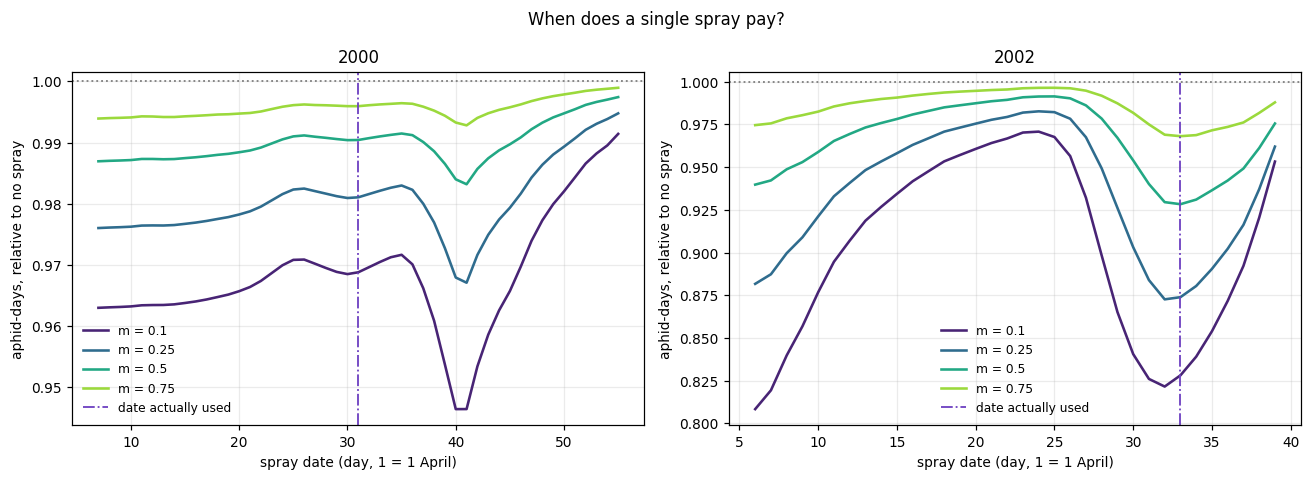

In [21]:
def outcomes(year, spray_day, m, predators=1.0):
    g = df[df.year == year].sort_values("t")
    spray = () if m >= 0.999 else (float(spray_day), float(m))
    t, N = sv.simulate(g, weather, scaler, beta_s, year, spray=spray, P_scale=predators)
    return N.max(), float(np.trapz(N, t))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
for ax, year in zip(axes, (2000, 2002)):
    g = df[df.year == year]
    days = np.arange(int(g.t.min()) + 1, int(g.t.max()))
    survs = np.array([0.1, 0.25, 0.5, 0.75])
    base = outcomes(year, 0, 1.0)[1]
    for s_, c in zip(survs, plt.cm.viridis(np.linspace(0.1, 0.85, len(survs)))):
        ad = [outcomes(year, d_, s_)[1] for d_ in days]
        ax.plot(days, np.array(ad) / base, color=c, lw=1.7, label=f"m = {s_}")
    ax.axhline(1.0, color="0.5", ls=":", lw=1.2)
    if year in gpd.SPRAY_DATES:
        ax.axvline(gpd._day_index(*gpd.SPRAY_DATES[year]), color="#6f42c1",
                   lw=1.2, ls="-.", label="date actually used")
    ax.set(xlabel="spray date (day, 1 = 1 April)",
           ylabel="aphid-days, relative to no spray", title=str(year))
    ax.legend(fontsize=8)
fig.suptitle("When does a single spray pay?")
plt.tight_layout(); plt.show()

## 9. The fold model, and what the data actually support

Non-dimensionalise Eq. (5) with $n = N/d$, $\tau = r m t$:

$$\frac{dn}{d\tau} = n\left(1 - \frac{n}{\kappa}\right) - \rho\,\frac{n^2}{n^2+1},
\qquad \kappa = \frac{K}{e\,d},\quad \rho = \frac{Pk}{rmd}$$

Four parameters collapse to two groups, and the fit drives $\kappa\to\infty$, so
what is left is a **one-parameter** system whose interior equilibria solve
$n^2 - \rho n + 1 = 0$:

$$n_\pm = \frac{\rho \pm \sqrt{\rho^2-4}}{2}, \qquad \text{real iff } \rho \ge 2$$

That is a **fold**, a saddle-node in one control, and the *simplest* object in the
catastrophe hierarchy. Not the cusp the paper fits, and not the swallowtail one
might climb to. And $\rho = 2$ is exactly the $P^* = 2drm/k$ threshold that keeps
reappearing. This is Ludwig, Jones & Holling's (1978) spruce budworm model, where
insect-outbreak bistability has lived for fifty years.

The paper explicitly ruled the fold out at the start: *"we do not consider the
fold and swallowtail catastrophe models because stable behavior cannot be observed
in these two"*, which is backwards for its own data.

### The model, with weather where it can matter

$$\frac{dN}{dt} = r(e)\,N\left(1-\frac{N}{K}\right) - \frac{P\,k\,N^2}{N^2+d^2},
\qquad r(e) = r_0 + a\,e$$

Two deliberate choices:

* **$r(e)$ is linear, so it can go negative.** In cold, wet weather the population
  shrinks unaided, real mortality that has to live somewhere. (The paper itself
  invokes rainfall "washing" aphids off the crop in 2002.)
* **$K$ is fixed, not fitted**, set from agronomy, with a sensitivity check.
  Fitting it is precisely what hollowed out the published model.

An earlier version put weather on predation as $k(e)=k_0e^{ce}$. It fitted *better*
(pooled $R^2_{\log}$ 0.645) and was nonsense: the optimiser bought low-$e$ mortality
by inflating predation to a median of 540 and a maximum of 45 000 aphids per
predator unit per day, against a literature range of 50–150 for an adult
*Coccinella septempunctata*. An unbounded exponential on a rate with a hard
biological ceiling will always be abused that way. `k` is a bounded constant here.

In [22]:
import fold_model as fm
beta_f = fm.FITTED
print("fold model parameters (trajectory-matched on 1997-2001):")
for nm in fm.PARAM_NAMES:
    print(f"  {nm:<3} = {beta_f[nm]:>10,.4f}")
print(f"\n  r(e) ranges {float(fm.r_of(df.e.min(), beta_f)):+.4f} to "
      f"{float(fm.r_of(df.e.max(), beta_f)):+.4f} per day")
print(f"  k  = {beta_f['k']:.1f} aphids/PU/day   (literature 50-150)")
print(f"  d  = {beta_f['d']:.0f} aphids/100 stems (data median "
      f"{df.N.median():.0f}, max {df.N.max():.0f})")
print(f"  K  = {fm.K_FIXED:,.0f}  FIXED, not fitted")

rho = fm.rho(df.e.to_numpy(), df.P.to_numpy(), beta_f)
rv = fm.r_of(df.e.to_numpy(), beta_f)
print(f"\nregime of each of the 62 survey dates:")
print(f"  bistable  (rho >= 2, r > 0): {int(((rho>=2) & np.isfinite(rho)).sum()):3d}")
print(f"  escaping  (rho <  2, r > 0): {int(((rho<2) & (rv>0)).sum()):3d}")
print(f"  declining (r <= 0)         : {int((rv<=0).sum()):3d}")

fold model parameters (trajectory-matched on 1997-2001):
  r0  =     0.2888
  a   =     0.1205
  k   =   156.4000
  d   =   906.3300

  r(e) ranges -0.1491 to +0.5176 per day
  k  = 156.4 aphids/PU/day   (literature 50-150)
  d  = 906 aphids/100 stems (data median 346, max 7480)
  K  = 10,000  FIXED, not fitted

regime of each of the 62 survey dates:
  bistable  (rho >= 2, r > 0):  28
  escaping  (rho <  2, r > 0):  31
  declining (r <= 0)         :   3


In [23]:
# closed form vs numerically solving the full model with its ceiling
print("  e     P    rho     closed form (refuge, threshold)      full model incl. ceiling")
for e_, P_ in [(-0.5, 2.0), (0.0, 5.0), (0.5, 9.0), (1.5, 20.0)]:
    r_ = float(fm.rho(e_, P_, beta_f))
    cl, nu = fm.equilibria(e_, P_, beta_f), fm.equilibria(e_, P_, beta_f, closed=False)
    f = lambda arr: ", ".join(f"{v:8.1f}" for v in arr) if len(arr) else "none"
    print(f"  {e_:+4.1f} {P_:5.1f} {r_:7.3f}   {f(cl):34s} {f(nu)}")

print("\nsensitivity to the FIXED ceiling K:")
for row in fm.sensitivity_K(df, weather, scaler, beta_f):
    print(f"   K = {row['K']:>9,.0f}  ->  pooled log-R^2 = {row['r2_log']:.4f}")

  e     P    rho     closed form (refuge, threshold)      full model incl. ceiling
  -0.5   2.0   1.510   none                                 8387.0
  +0.0   5.0   2.988      348.1,   2359.6                    332.8
  +0.5   9.0   4.449      215.2,   3817.5                    210.1
  +1.5  20.0   7.350      125.7,   6536.0                    124.1

sensitivity to the FIXED ceiling K:


   K =     8,000  ->  pooled log-R^2 = 0.5434
   K =    10,000  ->  pooled log-R^2 = 0.5625
   K =    20,000  ->  pooled log-R^2 = 0.5340
   K =    50,000  ->  pooled log-R^2 = 0.4833
   K =   100,000  ->  pooled log-R^2 = 0.4482


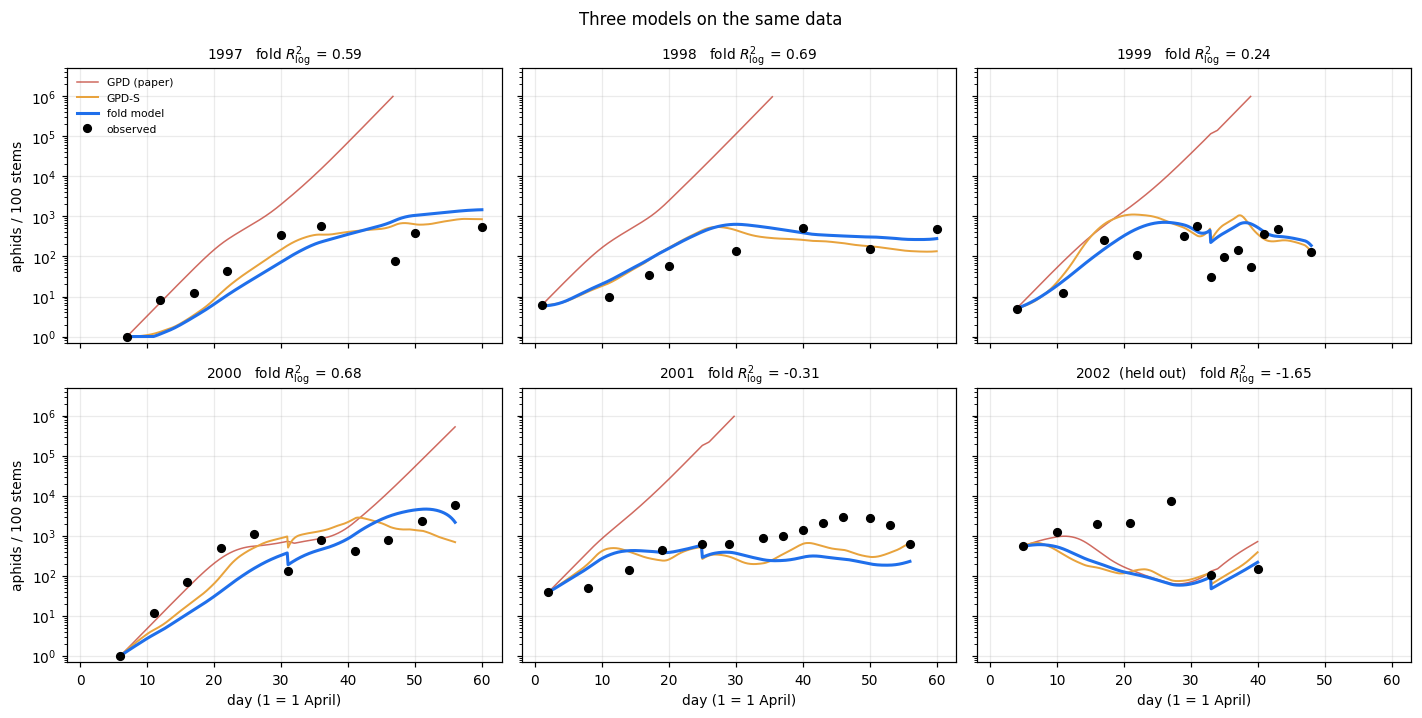

,year,obs_peak,fold_peak,r2_log
0,1997,591.0,1466.437,0.589
1,1998,527.0,634.394,0.686
2,1999,562.0,711.895,0.241
3,2000,5870.0,4646.099,0.677
4,2001,2958.0,580.399,-0.308
5,2002,7480.0,602.710,-1.650


In [24]:
fig, axes = plt.subplots(2, 3, figsize=(13, 6.6), sharex=True, sharey=True)
rows = []
for ax, year in zip(axes.ravel(), YEARS):
    g = df[df.year == year].sort_values("t")
    tf, Nf = fm.simulate(g, weather, scaler, beta_f, year)
    ts, Ns = sv.simulate(g, weather, scaler, sv.FITTED, year)
    tg, Ng, _b = gpd.simulate_season(g, weather, scaler, gpd.PAPER_BETA, year)
    ax.plot(tg, np.maximum(Ng, 1), color="#c0392b", lw=1.0, alpha=.75, label="GPD (paper)")
    ax.plot(ts, np.maximum(Ns, 1), color="#e8a33d", lw=1.3, label="GPD-S")
    ax.plot(tf, np.maximum(Nf, 1), color="#1f6feb", lw=2.0, label="fold model")
    ax.plot(g.t, np.maximum(g.N, 1), "o", color="k", ms=5, zorder=5, label="observed")
    r2 = gpd.r_squared(np.log1p(g.N),
                       np.log1p(np.interp(g.t.to_numpy(float), tf, Nf)))
    rows.append(dict(year=year, obs_peak=g.N.max(), fold_peak=Nf.max(), r2_log=r2))
    ax.set_yscale("log"); ax.set_ylim(0.7, 5e6)
    ax.set_title(f"{year}" + ("  (held out)" if year == gpd.TEST_YEAR else "")
                 + f"   fold $R^2_{{\log}}$ = {r2:.2f}", fontsize=9)
axes[0, 0].legend(fontsize=7, loc="upper left")
for ax in axes[1]: ax.set_xlabel("day (1 = 1 April)")
for ax in axes[:, 0]: ax.set_ylabel("aphids / 100 stems")
fig.suptitle("Three models on the same data")
plt.tight_layout(); plt.show()
pd.DataFrame(rows).round(3)

### Verdict on the fold model

It is the **right structure** and an **honest fit**, and those are different things.

Right structure: one control variable with a closed-form bifurcation, four
identifiable parameters, `k` and `d` both biologically plausible, and results that
barely move as the fixed ceiling varies over an order of magnitude.

Honest fit: pooled $R^2_{\log}$ = 0.56 on the fitted years, *lower* than the
biologically indefensible exponential variant (0.645) and than GPD-S (0.614). It
tracks 1997, 1998 and 2000 well, misses 1999 and 2001, and fails on the held-out
2002 exactly as both other models do.

All three models fail on the same years, which is the real finding: **the failure
is in the data, not the functional form.** `e` and `P` do not contain enough
information to explain why 2000 and 2002 exploded while 1997 and 1998 stayed
quiet. No amount of re-specifying the right-hand side fixes a missing covariate , 
which is why the next step is new *inputs* (immigration, crop growth stage,
predator dynamics), not a better curve.

## 10. Does the classification actually predict outbreaks?

The paper's regions are meant to mean I = safe, III = outbreak. That is testable:
take the region at the *start* of each between-survey interval and look at the
growth that followed.

Note one structural point first, **the region is a function of $(e, P, m)$ only.
$N$ never enters it.** So it classifies *conditions*, not the state of the
population, and cannot in principle report that a population has jumped.

In [25]:
from scipy import stats

rows = []
for y, g in df.groupby("year"):
    g = g.sort_values("t").reset_index(drop=True)
    for i in range(len(g) - 1):
        n0, n1 = max(g.N[i], 1.0), max(g.N[i + 1], 1.0)
        rows.append(dict(year=y, no=g.no[i], region=g.region[i], e=g.e[i], P=g.P[i],
                         N0=g.N[i], N1=g.N[i + 1],
                         rate=np.log(n1 / n0) / (g.t[i + 1] - g.t[i])))
iv = pd.DataFrame(rows)

print("realised growth rate  log(N1/N0)/dt,  by region at the start of the interval")
print(iv.groupby("region").rate.agg(["count", "mean", "median", "std"]).round(4))
print("\nfraction of intervals in which the population increased")
print(iv.assign(up=iv.rate > 0).groupby("region").up.mean().round(3).to_string())
print()
for a, c in [("I", "III"), ("I", "II"), ("II", "III")]:
    _u, p = stats.mannwhitneyu(iv[iv.region == a].rate, iv[iv.region == c].rate,
                               alternative="two-sided")
    print(f"  Mann-Whitney {a:<3} vs {c:<3}:  p = {p:.3f}")

print("\nsimpler predictors of the same growth rate")
for name, col in [("starting density N0", iv.N0), ("predators P", iv.P),
                  ("weather index e", iv.e)]:
    rho, p = stats.spearmanr(col, iv.rate)
    print(f"  {name:<22} rho = {rho:+.3f}   p = {p:.4f}")

realised growth rate  log(N1/N0)/dt,  by region at the start of the interval
        count    mean  median     std
region                               
I          26  0.1805  0.1306  0.2525
II         15 -0.1076  0.0531  0.4572
III        15  0.1060  0.1552  0.2596

fraction of intervals in which the population increased
region
I      0.885
II     0.600
III    0.733

  Mann-Whitney I   vs III:  p = 0.561
  Mann-Whitney I   vs II :  p = 0.041
  Mann-Whitney II  vs III:  p = 0.158

simpler predictors of the same growth rate
  starting density N0    rho = -0.534   p = 0.0000
  predators P            rho = -0.397   p = 0.0025
  weather index e        rho = -0.181   p = 0.1825


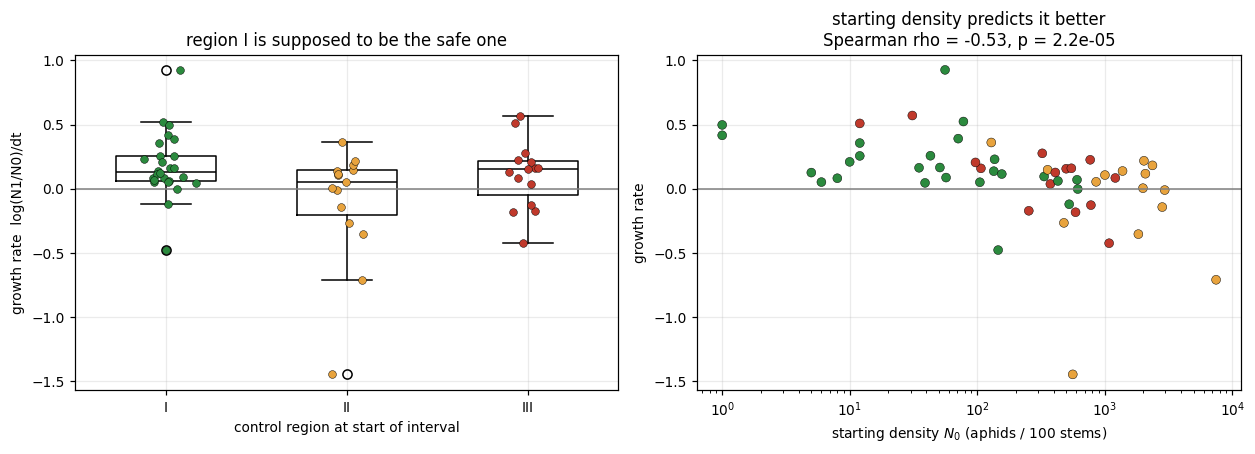

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))
order = ["I", "II", "III"]
ax = axes[0]
ax.boxplot([iv[iv.region == r_].rate for r_ in order], labels=order, widths=0.55,
           medianprops=dict(color="k"))
for i, r_ in enumerate(order, start=1):
    v = iv[iv.region == r_].rate
    ax.scatter(np.random.normal(i, 0.055, len(v)), v, s=26, color=RCOL[r_],
               edgecolor="k", linewidth=0.3, zorder=4)
ax.axhline(0, color="0.5", lw=1)
ax.set(xlabel="control region at start of interval",
       ylabel="growth rate  log(N1/N0)/dt",
       title="region I is supposed to be the safe one")

ax = axes[1]
ax.scatter(np.maximum(iv.N0, 1), iv.rate, s=34,
           c=[RCOL[r_] for r_ in iv.region], edgecolor="k", linewidth=0.3)
ax.set_xscale("log"); ax.axhline(0, color="0.5", lw=1)
rho, p = stats.spearmanr(iv.N0, iv.rate)
ax.set(xlabel="starting density $N_0$ (aphids / 100 stems)",
       ylabel="growth rate", title=f"starting density predicts it better\n"
                                   f"Spearman rho = {rho:.2f}, p = {p:.1e}")
plt.tight_layout(); plt.show()

### Verdict

| claim | holds? |
|---|---|
| tables and arithmetic reproduce | **yes**, 62/62 regions, $e$ to $10^{-3}$ |
| CP weather index is well-constructed | **yes** |
| bistability requires $P > 2drm/k$ | **yes**, clean and checkable |
| Eq. (5) works as a population model | **no**, cannot be integrated |
| regions predict outbreaks | **no**, I vs III, p ≈ 0.56 |
| the identified transitions are catastrophes | **no**, gradual changes, relabelled |

The paper is internally consistent and its catastrophe algebra is correct, but on
the six seasons it was built from the classification carries no demonstrated
predictive power beyond "are there many predators". Its 1997 headline transition,
NO5 (335) → NO6 (591), is ×1.76 over six days, 9.9%/day, ordinary aphid growth.
The label changed because $e$ crossed zero, not because $N$ did anything abrupt.

Caveat: n = 56 intervals across 6 seasons rules out a *large* effect, not a subtle one.

**Also worth noting**, Section 3.3.1 states *"In 1999, sudden jumps occurred from
NO 26 (5) to NO 27 (12)"*, but in the paper's own Table 3 NO26 = 146 and NO27 = 56.
The values 5 and 12 belong to **NO18 and NO19**. The narrative (early April,
jointing stage, no aphids yet) confirms NO18→19 was meant. The second citation in
that sentence, NO25 (97) → NO26 (146), is correct.

---
## Reference

| module | contents |
|---|---|
| `src/gpd.py` | the paper's model verbatim, data loading, CP method, cusp algebra, two-stage estimation |
| `src/sim_variant.py` | GPD-S: the integrable variant, equilibria, calibration |
| `src/extract_tables.py` | pulls Tables 3 and A2 out of the article PDF |
| `src/run_analysis.py` | batch run: writes every figure to `figures/` and tables to `out/` |

```bash
python3 src/extract_tables.py     # rebuild the reference tables from the PDF
python3 src/run_analysis.py       # all figures and summary tables
python3 src/run_analysis.py --refit-sim   # also re-run the GPD-S global search
```